In [4]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os
import pandas as pd

BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID"

for folder in os.listdir(BASE_DIR):

    folder_path = os.path.join(BASE_DIR, folder)

    if os.path.isdir(folder_path):

        roc_path = os.path.join(folder_path, "test_predictions.csv")

        if os.path.exists(roc_path):

            df = pd.read_csv(roc_path)

            y_true = df["true_label"]
            y_prob = df["prob_positive"]

            fpr, tpr, _ = roc_curve(y_true, y_prob)
            roc_auc = auc(fpr, tpr)

            # 🔥 PENTING: figure baru tiap model
            plt.figure(figsize=(8,6))

            plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
            plt.plot([0,1],[0,1],'k--')

            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"ROC Curve - {folder}")
            plt.legend()
            plt.grid()

            # 🔥 save ke dalam folder masing-masing
            save_path = os.path.join(folder_path, f"roc_curve_{folder}.png")

            plt.savefig(save_path, dpi=300)
            plt.close()  # 🔥 penting biar tidak numpuk di memori

            print(f"✅ ROC saved: {save_path}")

        else:
            print(f"❌ Tidak ada CSV di {folder}")

✅ ROC saved: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/4.S/roc_curve_4.S.png
✅ ROC saved: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/2.L/roc_curve_2.L.png
✅ ROC saved: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/1.RAW/roc_curve_1.RAW.png
✅ ROC saved: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/5.R.L/roc_curve_5.R.L.png
✅ ROC saved: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/6.R-S/roc_curve_6.R-S.png
✅ ROC saved: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/7.L-S/roc_curve_7.L-S.png
✅ ROC saved: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/8.R-L-S/roc_curve_8.R-L-S.png
✅ ROC saved: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/3_R/roc_curve_3_R.png


In [ ]:
#INFO PYTHON GUGEL COLLAB

import sys
import torch
import platform
import psutil

print("Python version:", sys.version)
print("Platform:", platform.platform())

print("\nCPU:")
print(platform.processor())

print("\nRAM:")
print(f"{psutil.virtual_memory().total / (1024**3):.2f} GB")

print("\nGPU:")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35

CPU:
x86_64

RAM:
176.88 GB

GPU:
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
# =====================================================
# BARENGAN DOWNLOAD 8 CM MODEL
# =====================================================

import os
import shutil
import zipfile

# =====================================================
# PATH MODEL
# =====================================================
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/BiGRU_BASELINE"

# folder temporary untuk kumpulkan gambar
OUTPUT_DIR = "/content/confusion_matrix_collection_DISTILBERT_BASELINE"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================
# LOOP SEMUA MODEL
# =====================================================
for folder in os.listdir(BASE_DIR):

    folder_path = os.path.join(BASE_DIR, folder)

    if os.path.isdir(folder_path):

        cm_path = os.path.join(folder_path, "confusion_matrix.png")

        if os.path.exists(cm_path):

            # ambil nama preprocessing
            model_name = folder.split(".")[1]

            new_name = f"confusion_matrix_{model_name}.png"

            dst = os.path.join(OUTPUT_DIR, new_name)

            shutil.copy(cm_path, dst)

            print("Copied:", new_name)

# =====================================================
# ZIP SEMUA FILE
# =====================================================
zip_path = "/content/confusion_matrices.BiGRU_BASELINE.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for file in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, file), file)

print("ZIP created:", zip_path)

# =====================================================
# DOWNLOAD
# =====================================================
from google.colab import files
files.download(zip_path)

ZIP created: /content/confusion_matrices.BiGRU_BASELINE.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#RENAME SEMUA KOLOM PERTAMA MENJADI CLASS
import os
import pandas as pd

base_dir = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE"

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == "classification_report.csv":

            path = os.path.join(root, file)

            # baca csv
            df = pd.read_csv(path)

            # rename kolom pertama
            df.rename(columns={df.columns[0]: "class"}, inplace=True)

            # simpan kembali
            df.to_csv(path, index=False)

            print(f"Updated: {path}")

Updated: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/8.R.L.S.20260309_213526/classification_report.csv
Updated: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/1.ARW.20260309_161922/classification_report.csv
Updated: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/2.L.20260309_164954/classification_report.csv
Updated: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/3.R.20260309_171606/classification_report.csv
Updated: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/4.S.20260309_173028/classification_report.csv
Updated: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/5.R.L.20260309_180817/classification_report.csv
Updated: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/6.R.S.20260309_182501/classification_report.csv
Updated: /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/7.L.S.20260309_211701/classification_report.

# **REKAP PLOT DAN TABEL**

In [ ]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX"

for root, dirs, files in os.walk(BASE_DIR):

    if "training_log.csv" in files:

        path = os.path.join(root, "training_log.csv")

        df = pd.read_csv(path)

        if "Val_Acc" in df.columns:

            df = df.rename(columns={"Val_Acc": "val_acc"})

            df.to_csv(path, index=False)

            print("Renamed:", path)

   Model Preprocessing  Accuracy  Precision  Recall  F1-score
0  BiGRU            P1    0.8532   0.853265  0.8532  0.853193
1  BiGRU            P2    0.8592   0.860030  0.8592  0.859119
2  BiGRU            P3    0.8682   0.868405  0.8682  0.868182
3  BiGRU            P4    0.8462   0.846284  0.8462  0.846191
4  BiGRU            P5    0.8638   0.863880  0.8638  0.863793
5  BiGRU            P6    0.8530   0.853371  0.8530  0.852961
6  BiGRU            P7    0.8446   0.844660  0.8446  0.844593
7  BiGRU            P8    0.8552   0.856048  0.8552  0.855114
         Model Preprocessing  Accuracy  Precision  Recall  F1-score
8   DistilBERT            P1    0.8832   0.883200  0.8832  0.883200
9   DistilBERT            P2    0.8770   0.877133  0.8770  0.876989
10  DistilBERT            P3    0.8810   0.881362  0.8810  0.880972
11  DistilBERT            P4    0.8540   0.854000  0.8540  0.854000
12  DistilBERT            P5    0.8796   0.880029  0.8796  0.879566
13  DistilBERT            P6    0.

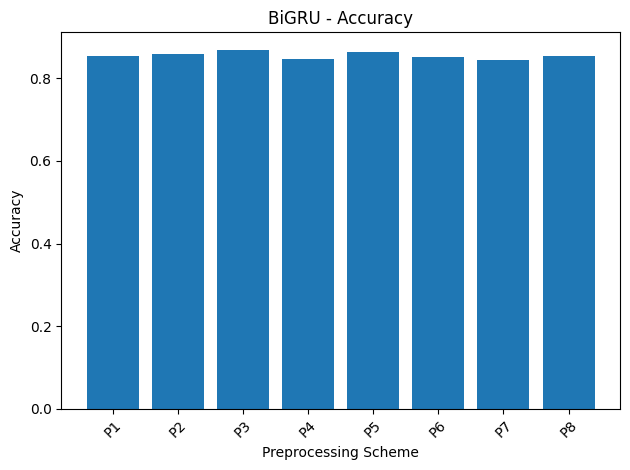

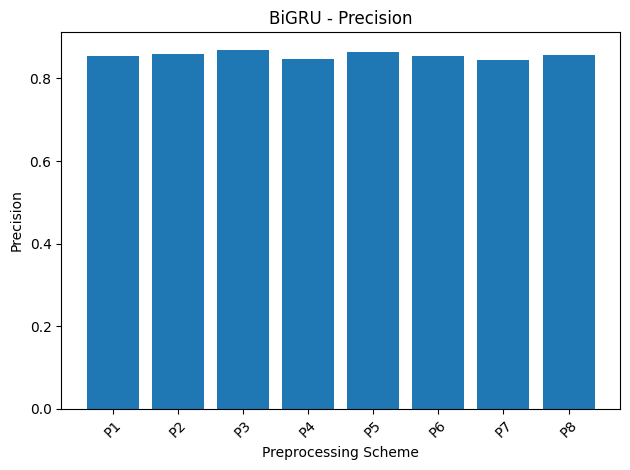

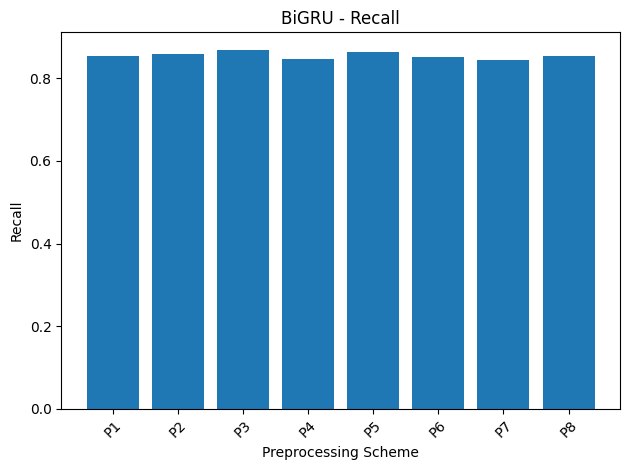

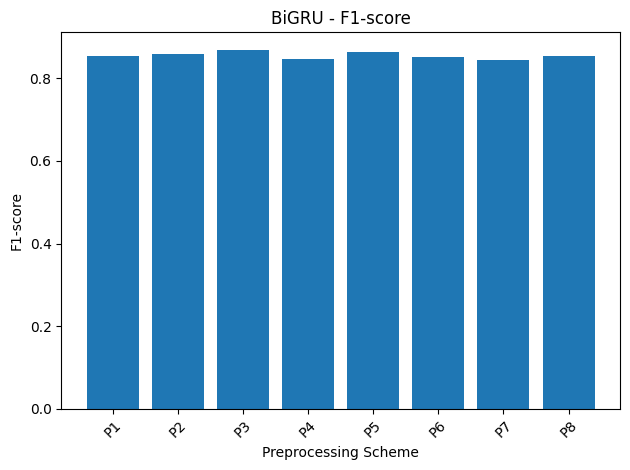

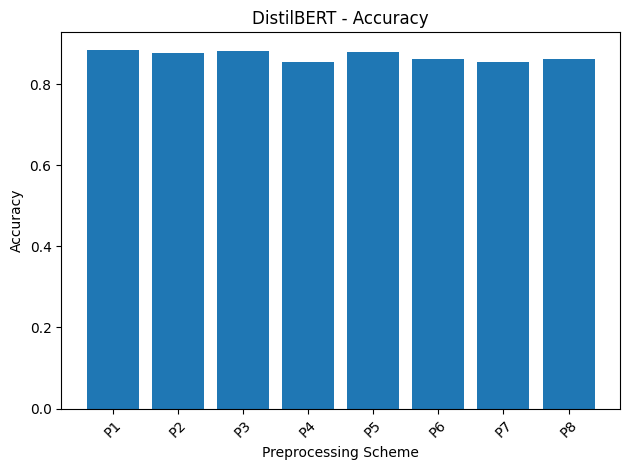

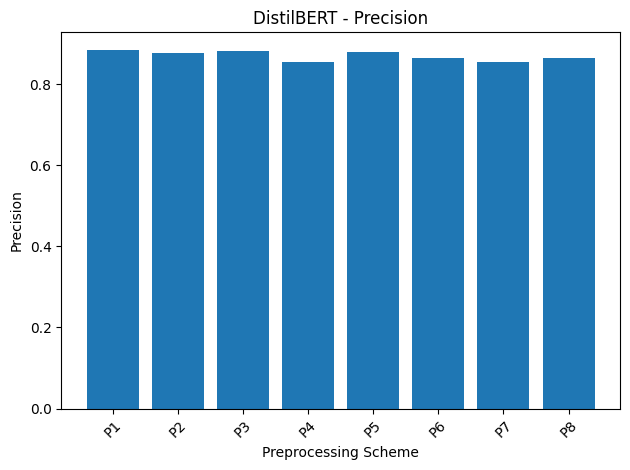

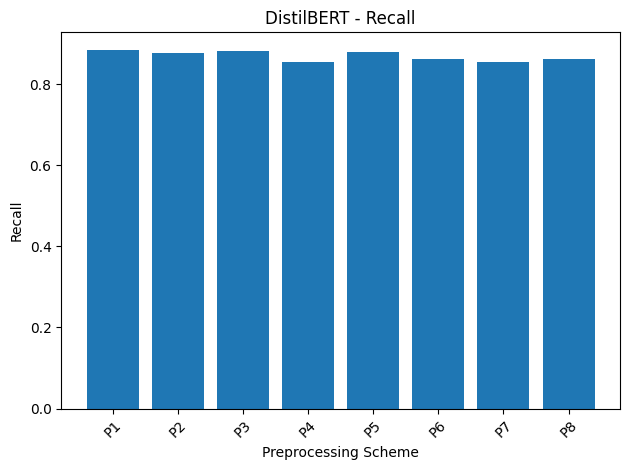

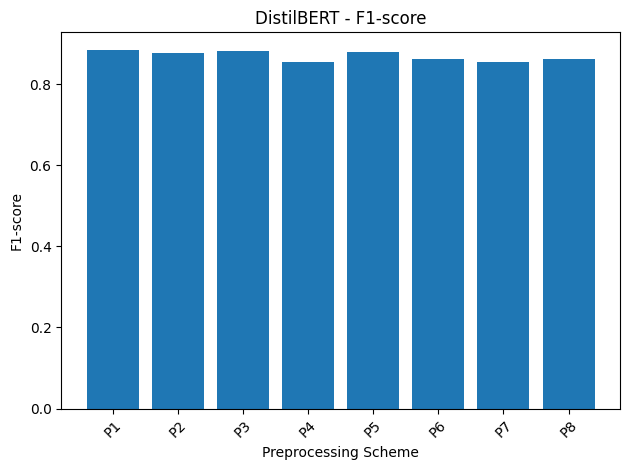

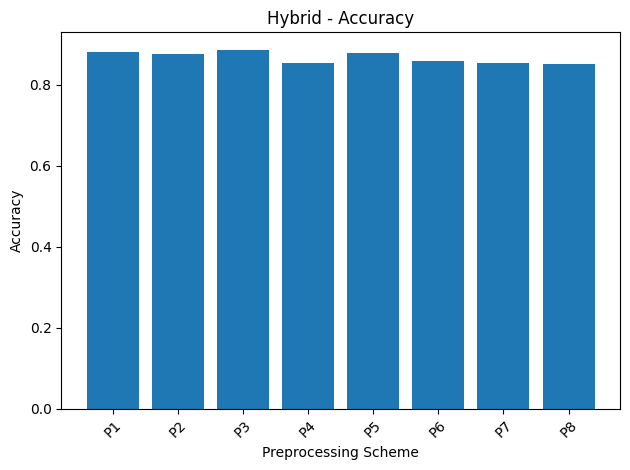

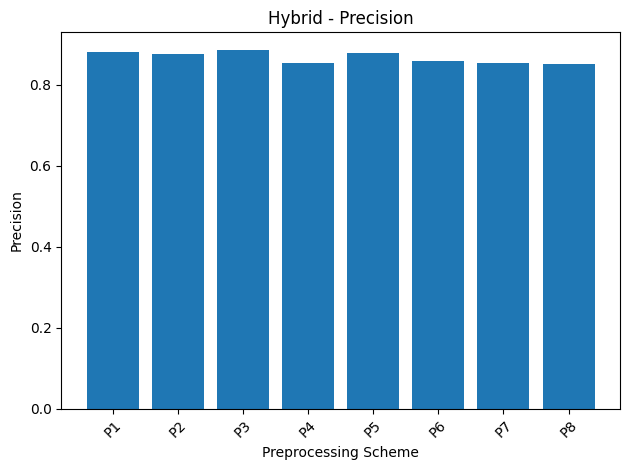

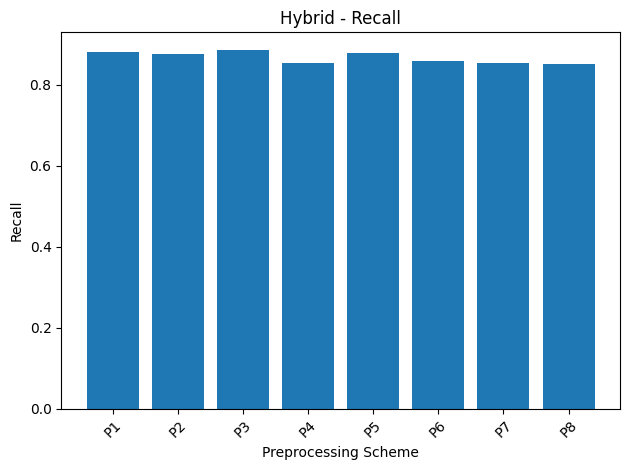

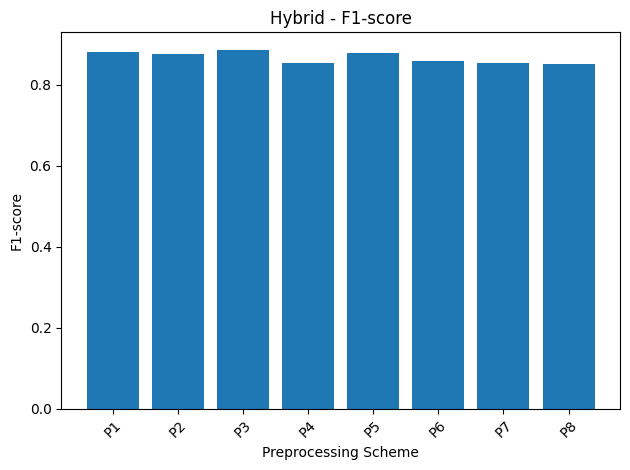

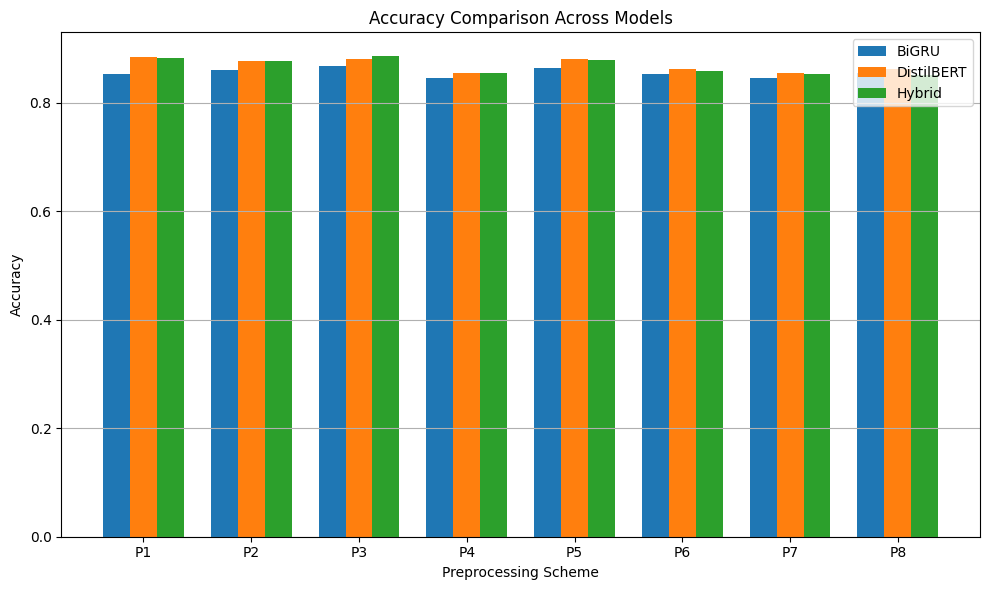

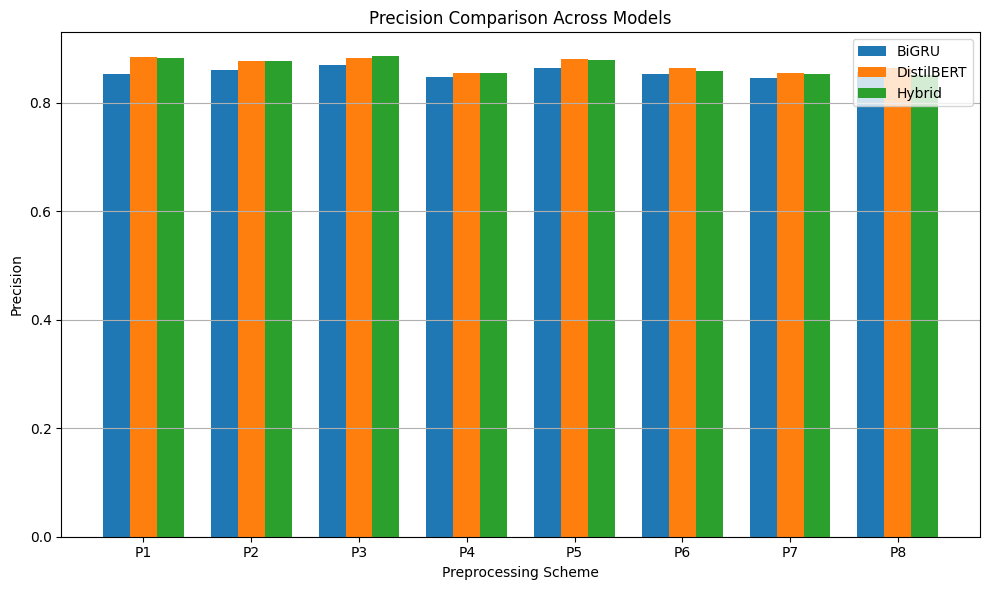

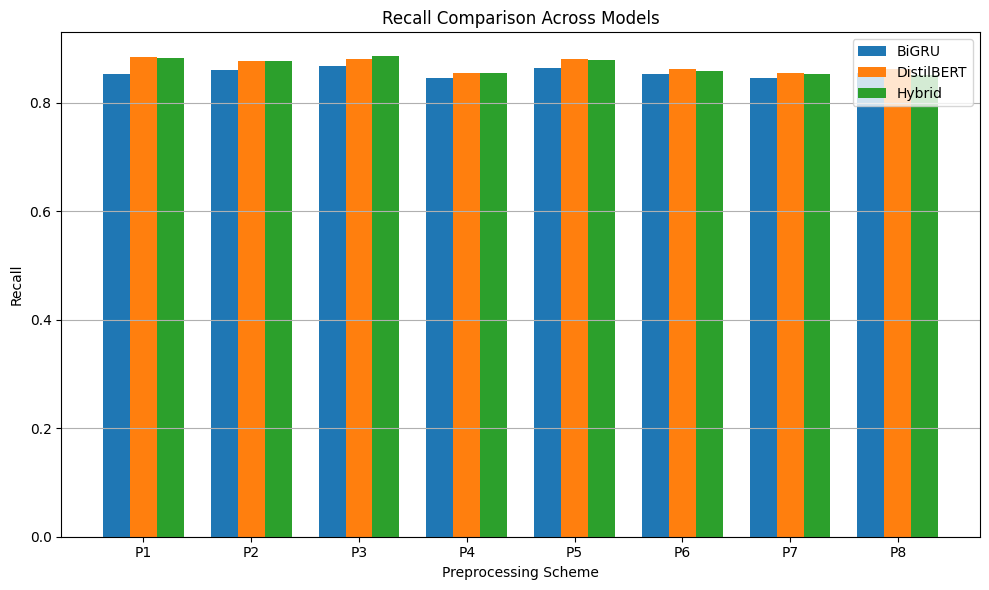

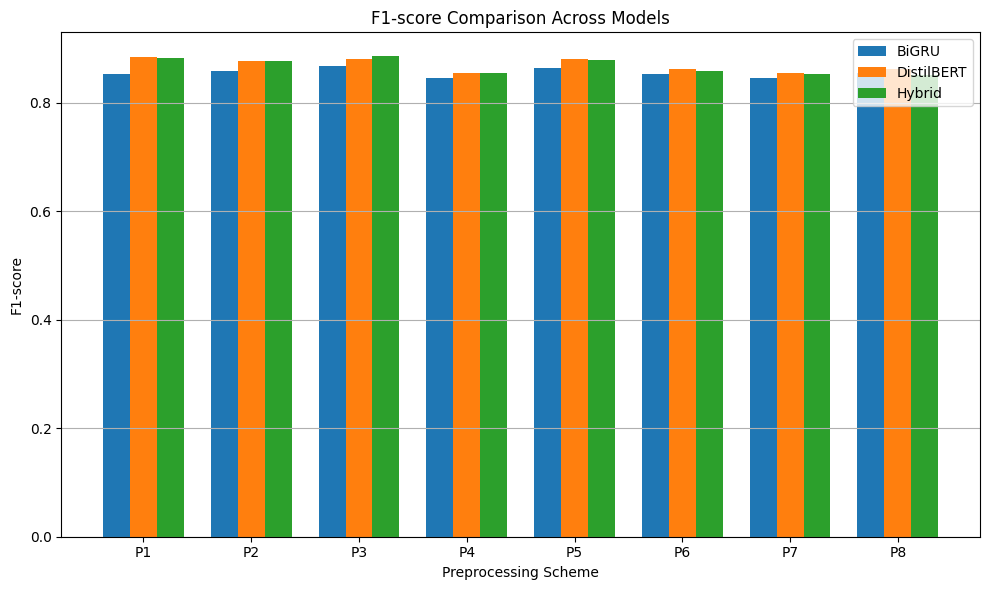

'\n  #================================================\n# LEARNING CURVE ALL\n#================================================\n\n#================================================\n# LEARNING CURVE ALL\n#================================================\n\nfor model, model_path in MODELS.items():\n\n    plt.figure()\n\n    folders = sorted([\n        f for f in os.listdir(model_path)\n        if os.path.isdir(os.path.join(model_path, f))\n    ])\n\n    for folder in folders:\n\n        history_path = os.path.join(model_path, folder, "training_log.csv")\n\n        if os.path.exists(history_path):\n\n            hist = pd.read_csv(history_path)\n\n            plt.plot(hist["val_acc"], label=folder)\n\n    plt.title(f"{model} Validation Accuracy Curve")\n\n    plt.xlabel("Epoch")\n    plt.ylabel("Validation Accuracy")\n\n    plt.legend()\n\n    plt.tight_layout()\n\n    plt.savefig(f"{model}_learning_curve.png")\n\n    plt.show()\n\n#PERBANDINGAN ANTAR MODEL\npivot_acc = results_df.pivot(

In [4]:
#================================================
#Setup Path dan Import Library
#================================================
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX"
csv_path= "classification_report.csv"
MODELS = {
    "BiGRU": f"{BASE_PATH}/BiGRU_BASELINE",
    "DistilBERT": f"{BASE_PATH}/DISTILBERT_BASELINE",
    "Hybrid": f"{BASE_PATH}/HYBRID"
}

#================================================
#Mengambil Metric dari classification_report.csv
#================================================
def extract_metrics(csv_path):

    df = pd.read_csv(csv_path)

    accuracy = df.loc[df['class']=="accuracy","f1-score"].values[0]

    precision = df.loc[df['class']=="weighted avg","precision"].values[0]
    recall = df.loc[df['class']=="weighted avg","recall"].values[0]
    f1 = df.loc[df['class']=="weighted avg","f1-score"].values[0]

    return accuracy, precision, recall, f1

#================================================
#MENGUMPULKAN SEMUA HASIL KE DATAFRAME
#================================================
results = []

for model_name, model_path in MODELS.items():

    folders = sorted([
        f for f in os.listdir(model_path)
        if os.path.isdir(os.path.join(model_path, f))
    ])

    for i, folder in enumerate(folders):

        csv_path = os.path.join(model_path, folder, "classification_report.csv")

        if os.path.exists(csv_path):

            acc, prec, rec, f1 = extract_metrics(csv_path)

            results.append({
                "Model": model_name,
                "Preprocessing": f"P{i+1}",
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-score": f1
            })

results_df = pd.DataFrame(results)


#================================================
#MEMBUAT 3 TABEL PER MODEL
#================================================
bigru_table = results_df[results_df.Model=="BiGRU"]
distilbert_table = results_df[results_df.Model=="DistilBERT"]
hybrid_table = results_df[results_df.Model=="Hybrid"]

print(bigru_table)
print(distilbert_table)
print(hybrid_table)

#================================================
#SAVE TO CSV
#================================================
bigru_table.to_csv("bigru_metrics.csv", index=False)
distilbert_table.to_csv("distilbert_metrics.csv", index=False)
hybrid_table.to_csv("hybrid_metrics.csv", index=False)

#================================================
# BAR PLOT METRIC
#================================================
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1-score"]

for model in MODELS.keys():

    df_model = results_df[results_df.Model == model]

    for metric in metrics:

        plt.figure()

        plt.bar(df_model["Preprocessing"], df_model[metric])

        plt.title(f"{model} - {metric}")
        plt.xlabel("Preprocessing Scheme")
        plt.ylabel(metric)

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.savefig(f"{model}_{metric}_barplot.png")

        plt.show()

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy","Precision","Recall","F1-score"]

for metric in metrics:

    plt.figure(figsize=(10,6))

    # pivot data
    pivot_df = results_df.pivot(
        index="Preprocessing",
        columns="Model",
        values=metric
    )

    x = np.arange(len(pivot_df.index))
    width = 0.25

    # plot 3 model berdampingan
    plt.bar(x - width, pivot_df["BiGRU"], width, label="BiGRU")
    plt.bar(x, pivot_df["DistilBERT"], width, label="DistilBERT")
    plt.bar(x + width, pivot_df["Hybrid"], width, label="Hybrid")

    plt.xticks(x, pivot_df.index)
    plt.xlabel("Preprocessing Scheme")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison Across Models")

    plt.legend()
    plt.grid(axis='y')

    plt.tight_layout()

    plt.savefig(f"{metric}_comparison.png", dpi=300)
    plt.show()
"""
  #================================================
# LEARNING CURVE ALL
#================================================

#================================================
# LEARNING CURVE ALL
#================================================

for model, model_path in MODELS.items():

    plt.figure()

    folders = sorted([
        f for f in os.listdir(model_path)
        if os.path.isdir(os.path.join(model_path, f))
    ])

    for folder in folders:

        history_path = os.path.join(model_path, folder, "training_log.csv")

        if os.path.exists(history_path):

            hist = pd.read_csv(history_path)

            plt.plot(hist["val_acc"], label=folder)

    plt.title(f"{model} Validation Accuracy Curve")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")

    plt.legend()

    plt.tight_layout()

    plt.savefig(f"{model}_learning_curve.png")

    plt.show()

#PERBANDINGAN ANTAR MODEL
pivot_acc = results_df.pivot(
    index="Preprocessing",
    columns="Model",
    values="Accuracy"
)

pivot_acc.plot(kind="bar")

plt.title("Accuracy Comparison Across Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("accuracy_model_comparison.png")

plt.show()

#PERBANDINGAN SEMUA METRIC

for metric in ["Accuracy","Precision","Recall","F1-score"]:

    pivot = results_df.pivot(
        index="Preprocessing",
        columns="Model",
        values=metric
    )

    pivot.plot(kind="bar")

    plt.title(f"{metric} Comparison Across Models")

    plt.ylabel(metric)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(f"{metric}_model_comparison.png")

    plt.show()



plt.savefig(os.path.join(OUTPUT_DIR, f"{model}_{metric}_barplot.png"))
#plt.savefig(os.path.join(OUTPUT_DIR, f"{model}_learning_curve.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_model_comparison.png"))

results_df.to_csv(os.path.join(OUTPUT_DIR,"results_all_experiments.csv"), index=False)

bigru_table.to_csv(os.path.join(OUTPUT_DIR,"bigru_results.csv"), index=False)

distilbert_table.to_csv(os.path.join(OUTPUT_DIR,"distilbert_results.csv"), index=False)

hybrid_table.to_csv(os.path.join(OUTPUT_DIR,"hybrid_results.csv"), index=False)

#LOOP SEMUA EKSPERIMEN
results = []

for model_name, model_path in MODELS.items():

    folders = sorted([
        f for f in os.listdir(model_path)
        if os.path.isdir(os.path.join(model_path, f))
    ])

    for i, folder in enumerate(folders):

        csv_path = os.path.join(model_path, folder, "classification_report.csv")

        if os.path.exists(csv_path):

            acc, prec, rec, f1 = extract_metrics(csv_path)

            results.append({
                "Model": model_name,
                "Preprocessing": folder,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-score": f1
            })
#TABEL PERBANDINGAN (UNTUK PAPER)
comparison_table = results_df.pivot( index="Preprocessing", columns="Model", values="Accuracy" )

comparison_table.to_csv(os.path.join(OUTPUT_DIR,"model_comparison_table.csv"))

OUTPUT_DIR = "/content/results_experiments"

os.makedirs(OUTPUT_DIR, exist_ok=True)
import shutil

zip_path = "/content/experiment_results.zip"

shutil.make_archive(
    zip_path.replace(".zip",""),
    'zip',
    OUTPUT_DIR
)

from google.colab import files

files.download(zip_path)
"""

# **REKAP METRIKS DALAM TABEL**

In [ ]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX"

MODELS = {
    "BiGRU": os.path.join(BASE_DIR,"BiGRU_BASELINE"),
    "DistilBERT": os.path.join(BASE_DIR,"DISTILBERT_BASELINE"),
    "Hybrid": os.path.join(BASE_DIR,"HYBRID")
}

#Fungsi Ambil Metric dari classification_report.csv
def extract_metrics(path):

    df = pd.read_csv(path)

    accuracy = df.loc[df["class"]=="accuracy","f1-score"].values[0]

    precision = df.loc[df["class"]=="weighted avg","precision"].values[0]
    recall = df.loc[df["class"]=="weighted avg","recall"].values[0]
    f1 = df.loc[df["class"]=="weighted avg","f1-score"].values[0]

    return accuracy, precision, recall, f1

#LOOP SEMUA EKSPERIMEN
results = []

for model_name, model_path in MODELS.items():

    folders = sorted(os.listdir(model_path))

    for i, folder in enumerate(folders):

        csv_path = os.path.join(model_path, folder, "classification_report.csv")

        if os.path.exists(csv_path):

            acc, prec, rec, f1 = extract_metrics(csv_path)

            results.append({
                "Model": model_name,
                "Preprocessing": f"Scheme_{i+1}",
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1-score": f1
            })

results_df = pd.DataFrame(results)

#TABEL REKAP 24 EKSPERIMEN
results_df

#TABEL PER MODEL
bigru_table = results_df[results_df.Model=="BiGRU"]
bigru_table

distilbert_table = results_df[results_df.Model=="DistilBERT"]
distilbert_table

hybrid_table = results_df[results_df.Model=="Hybrid"]
hybrid_table

#TABEL PERBANDINGAN (UNTUK PAPER)
comparison_table = results_df.pivot(
    index="Preprocessing",
    columns="Model",
    values="Accuracy"
)

comparison_table

#SIMPAN SEMUA TABEL
results_df.to_csv("all_model_metrics.csv", index=False)

bigru_table.to_csv("bigru_metrics.csv", index=False)

distilbert_table.to_csv("distilbert_metrics.csv", index=False)

hybrid_table.to_csv("hybrid_metrics.csv", index=False)

comparison_table.to_csv("model_accuracy_comparison.csv")

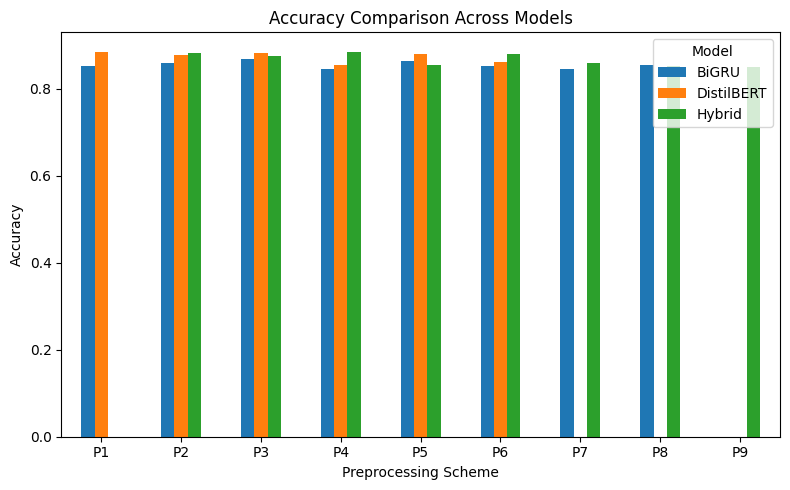

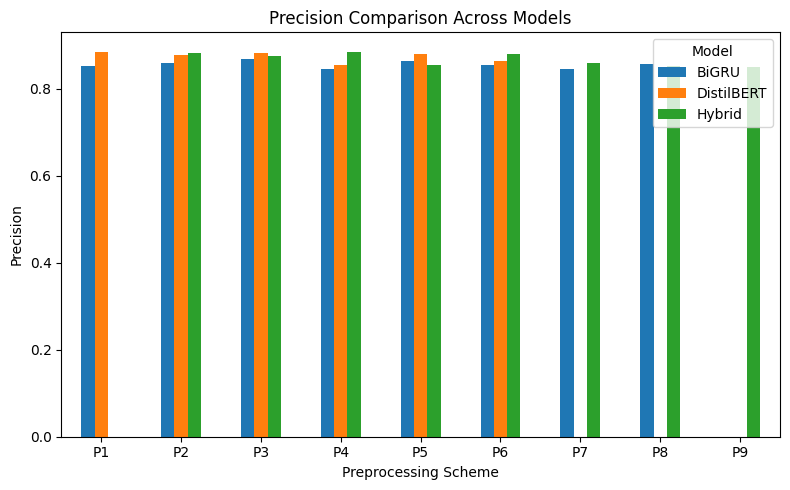

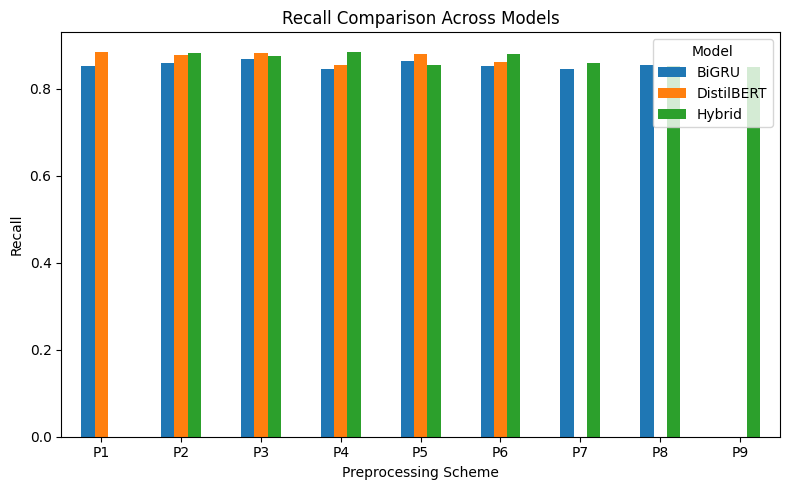

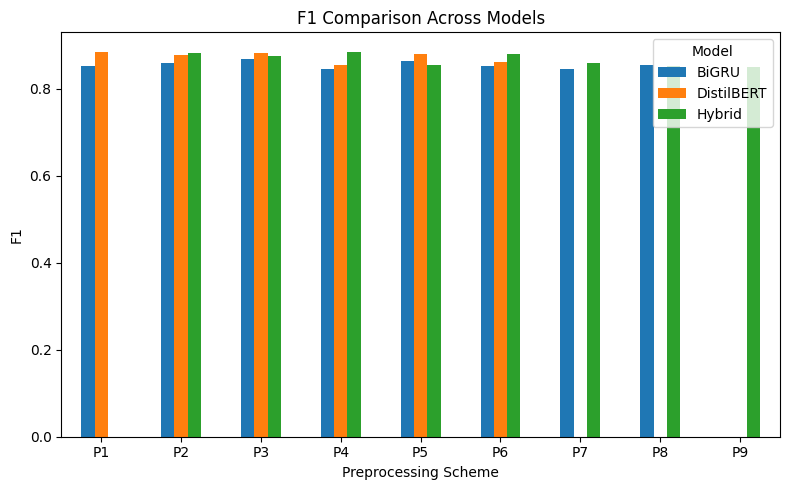

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX"

MODELS = {
    "BiGRU": os.path.join(BASE_DIR,"BiGRU_BASELINE"),
    "DistilBERT": os.path.join(BASE_DIR,"DISTILBERT_BASELINE"),
    "Hybrid": os.path.join(BASE_DIR,"HYBRID")
}

OUTPUT_DIR = os.path.join(BASE_DIR,"paper_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def extract_metrics(path):

    df = pd.read_csv(path)

    accuracy = df.loc[df["class"]=="accuracy","f1-score"].values[0]

    precision = df.loc[df["class"]=="weighted avg","precision"].values[0]
    recall = df.loc[df["class"]=="weighted avg","recall"].values[0]
    f1 = df.loc[df["class"]=="weighted avg","f1-score"].values[0]

    return accuracy, precision, recall, f1

#REKAP SEMUA EKSPERIMEN
results = []

for model_name, model_path in MODELS.items():

    folders = sorted(os.listdir(model_path))

    for i, folder in enumerate(folders):

        csv_path = os.path.join(model_path, folder, "classification_report.csv")

        if os.path.exists(csv_path):

            acc, prec, rec, f1 = extract_metrics(csv_path)

            results.append({
                "Model": model_name,
                "Preprocessing": f"P{i+1}",
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1
            })

results_df = pd.DataFrame(results)

results_df.to_csv(os.path.join(OUTPUT_DIR,"all_experiments_metrics.csv"), index=False)

results_df

#PREPROCESSING SCHEME
preprocess_table = pd.DataFrame({
    "Scheme":["P1","P2","P3","P4","P5","P6","P7","P8"],
    "Stemming":[0,0,0,1,0,1,1,1],
    "Lemmatization":[0,1,0,0,1,0,1,1],
    "Stopword_Removal":[0,0,1,0,1,1,0,1]
})

preprocess_table.to_csv(os.path.join(OUTPUT_DIR,"table_preprocessing_scheme.csv"), index=False)

preprocess_table

#MODEL PERFORMANCE COMPARISON
acc_table = results_df.pivot(
    index="Preprocessing",
    columns="Model",
    values="Accuracy"
)

f1_table = results_df.pivot(
    index="Preprocessing",
    columns="Model",
    values="F1"
)

table3 = pd.concat([acc_table.add_suffix("_Acc"),
                    f1_table.add_suffix("_F1")], axis=1)

table3.to_csv(os.path.join(OUTPUT_DIR,"table_model_performance.csv"))

table3

#GRAFIK PAPER READY

metrics = ["Accuracy","Precision","Recall","F1"]

for metric in metrics:

    pivot = results_df.pivot(
        index="Preprocessing",
        columns="Model",
        values=metric
    )

    pivot.plot(kind="bar", figsize=(8,5))

    plt.title(f"{metric} Comparison Across Models")

    plt.xlabel("Preprocessing Scheme")
    plt.ylabel(metric)

    plt.xticks(rotation=0)

    plt.legend(title="Model")

    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR,f"{metric}_comparison.png"),
        dpi=300
    )

    plt.show()

In [ ]:
results_df["Preprocessing"].unique()

array(['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9'], dtype=object)

In [ ]:
results_df[results_df["Preprocessing"]=="P9"]

,Model,Preprocessing,Accuracy,Precision,Recall,F1
21,Hybrid,P9,0.8504,0.850875,0.8504,0.850349


In [ ]:
#================================================
# DOWNLOAD SEMUA HASIL DARI FOLDER OUTPUT_DIR
#================================================
from google.colab import files
import shutil

# 1. Tentukan nama file zip
zip_name = "Hasil_Tesis_Indri_PaperReady"

# 2. Kompres folder OUTPUT_DIR menjadi file .zip
# shutil.make_archive akan membungkus seluruh isi folder 'paper_results'
shutil.make_archive(zip_name, 'zip', OUTPUT_DIR)

# 3. Download file zip tersebut ke komputer lokal
files.download(f"{zip_name}.zip")

print(f"Selesai! File {zip_name}.zip telah disiapkan untuk diunduh.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Selesai! File Hasil_Tesis_Indri_PaperReady.zip telah disiapkan untuk diunduh.


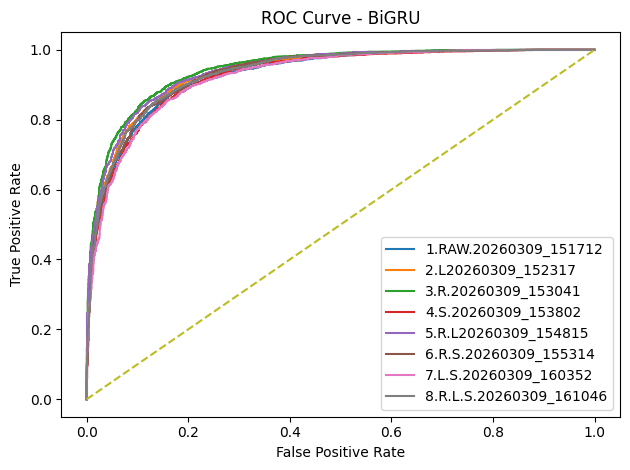

/tmp/ipykernel_4286/531417334.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


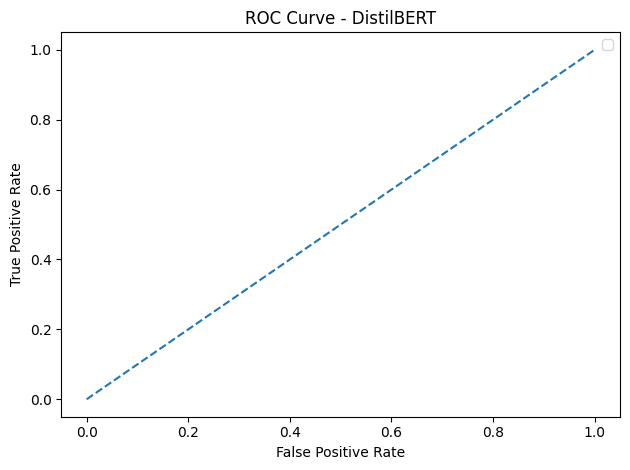

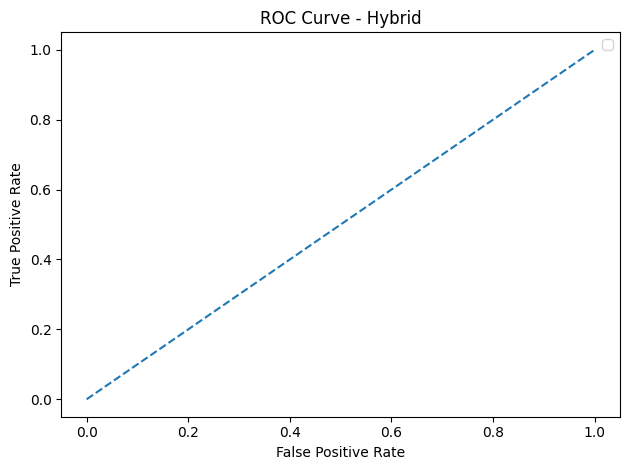

KeyError: 'Val_Acc'

<Figure size 640x480 with 0 Axes>

In [ ]:
#REKAP ROC CURVE NYA

# =====================================================
# DEFINE MODEL PATHS
# =====================================================


BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX"

MODELS = {
    "BiGRU": os.path.join(BASE_DIR,"BiGRU_BASELINE"),
    "DistilBERT": os.path.join(BASE_DIR,"DISTILBERT_BASELINE"),
    "Hybrid": os.path.join(BASE_DIR,"HYBRID")
}

OUTPUT_DIR = os.path.join(BASE_DIR,"paper_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)


import matplotlib.pyplot as plt
import pandas as pd
import os

for model, path in MODELS.items():

    plt.figure()

    folders = sorted(os.listdir(path))

    for folder in folders:

        roc_file = os.path.join(path, folder, "roc_curve.csv")

        if os.path.exists(roc_file):

            roc = pd.read_csv(roc_file)

            plt.plot(roc["fpr"], roc["tpr"], label=folder)

    plt.plot([0,1],[0,1], linestyle="--")

    plt.title(f"ROC Curve - {model}")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR,f"ROC_{model}.png"),
        dpi=300
    )

    plt.show()

#REKAP LEARNING CURVES
for model, path in MODELS.items():

    plt.figure()

    folders = sorted(os.listdir(path))

    for folder in folders:

        history_path = os.path.join(path, folder, "training_log.csv")

        if os.path.exists(history_path):

            hist = pd.read_csv(history_path)

            plt.plot(hist["Val_Acc"], label=folder)

    plt.title(f"Validation Accuracy Learning Curve - {model}")

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(OUTPUT_DIR,f"LearningCurve_{model}.png"),
        dpi=300
    )

    plt.show()


In [ ]:

#MC NEMAR FOR ALL

import seaborn as sns

heatmap_data = results_df.pivot(
    index="Preprocessing",
    columns="Model",
    values="Accuracy"
)

plt.figure(figsize=(6,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Accuracy Heatmap Across Models and Preprocessing")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR,"Accuracy_heatmap.png"),
    dpi=300
)

plt.show()

#PERFORMANCE RANKING PLOT

ranking_df = results_df.copy()

ranking_df["Rank"] = ranking_df.groupby("Model")["F1"].rank(
    ascending=False,
    method="min"
)

ranking_df

rank_pivot = ranking_df.pivot(
    index="Preprocessing",
    columns="Model",
    values="Rank"
)

rank_pivot

#RANKING PLOT
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for model in rank_pivot.columns:

    plt.plot(
        rank_pivot.index,
        rank_pivot[model],
        marker="o",
        label=model
    )

plt.gca().invert_yaxis()

plt.title("Ranking of Preprocessing Schemes Based on F1-score")

plt.xlabel("Preprocessing Scheme")

plt.ylabel("Performance Rank (Lower is Better)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR,"Preprocessing_Ranking_Plot.png"),
    dpi=300
)

plt.show()

#EXPERIMENT LANDSCAPE PLOT
landscape_df = results_df.copy()

landscape_df["Experiment"] = landscape_df["Model"] + "_" + landscape_df["Preprocessing"]

landscape_df

landscape_pivot = landscape_df.pivot(
    index="Experiment",
    values=["Accuracy","Precision","Recall","F1"]
)

landscape_pivot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,12))

sns.heatmap(
    landscape_pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("Experiment Performance Landscape")

plt.xlabel("Evaluation Metrics")

plt.ylabel("Model-Preprocessing Combination")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR,"Experiment_Landscape_Heatmap.png"),
    dpi=300
)

plt.show()

NameError: name 'results_df' is not defined

In [ ]:
import shutil

folder_path = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/paper_results"

zip_path = "/content/paper_results.zip"

shutil.make_archive("/content/paper_results", 'zip', folder_path)

print("ZIP file created:", zip_path)

from google.colab import files

files.download("/content/paper_results.zip")

In [ ]:
#PERBANDINGAN EVALUATION METRIC 3 MODEL
import pandas as pd

paths = {
    "DistilBERT-BiGRU": "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/HYBRID.1.RAW.20260219_223525/classification_report.csv",
    "Baseline BiGRU": "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/BIGRU_BASELINE/BiGRU_BASELINE.YEAH.1.RAW_20260306_220807/classification_report.csv",
    "Baseline DistilBERT": "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/DISTILBERT_BASELINE_1.RAW.20260307_141306/classification_report.csv"
}

dfs = {}

for model, path in paths.items():

    df = pd.read_csv(path)

    # ubah nama kolom pertama menjadi "class"
    df.rename(columns={df.columns[0]: "class"}, inplace=True)

    dfs[model] = df

    print(f"\n{model}")
    print(df.head())

for model, path in paths.items():

    df = pd.read_csv(path)

    df.rename(columns={df.columns[0]: "class"}, inplace=True)

    df.to_csv(path, index=False)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/HYBRID.1.RAW.20260219_223525/classification_report.csv'

In [ ]:
#REKAP PERBANDINGAN BASELINE VS HYBRID
import pandas as pd
from pathlib import Path

# ==============================
# PATH MODEL
# ==============================
paths = {
    "DistilBERT-BiGRU": "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/HYBRID.1.RAW.20260219_223525/classification_report.csv",
    "Baseline BiGRU": "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/BIGRU_BASELINE/BiGRU_BASELINE.YEAH.1.RAW_20260306_220807/classification_report.csv",
    "Baseline DistilBERT": "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/DISTILBERT_BASELINE_1.RAW.20260307_141306/classification_report.csv"
}

# ==============================
# FUNGSI EKSTRAK METRIK
# ==============================
import pandas as pd

def extract_metrics(path, model_name):
    df = pd.read_csv(path)

    weighted = df[df["class"] == "weighted avg"].iloc[0]
    accuracy = df[df["class"] == "accuracy"].iloc[0]

    return {
        "Model": model_name,
        "Accuracy": accuracy["f1-score"],
        "Precision": weighted["precision"],
        "Recall": weighted["recall"],
        "F1-score": weighted["f1-score"]
    }
# ==============================
# REKAP SEMUA MODEL
# ==============================
results = []

for model, path in paths.items():
    metrics = extract_metrics(path, model)
    results.append(metrics)

summary_table = pd.DataFrame(results)

# ==============================
# TAMPILKAN TABEL
# ==============================
summary_table = summary_table.sort_values("Accuracy", ascending=False)
print(summary_table)

# jika ingin simpan
summary_table.to_csv("rekap_metrics_model.csv", index=False)

In [ ]:
print(df.columns)
print(df.head())
print(df.dtypes)

Index(['Epoch', 'Train_Loss', 'Val_Loss', 'Train_Acc', 'Val_Acc', 'LR',
       'Epoch_Time(s)', 'Elapsed(s)'],
      dtype='object')
   Epoch  Train_Loss  Val_Loss  Train_Acc  Val_Acc        LR  Epoch_Time(s)  \
0      1    0.682422  0.657101   0.565225   0.7098  0.000001         924.67   
1      2    0.577788  0.463893   0.734375   0.7948  0.000001         914.15   
2      3    0.437316  0.384942   0.799300   0.8258  0.000001         946.26   
3      4    0.386205  0.357595   0.828225   0.8384  0.000001         939.29   
4      5    0.362473  0.342660   0.839850   0.8484  0.000001         942.50   

   Elapsed(s)  
0      924.67  
1     1838.82  
2     2785.08  
3     3724.38  
4     4666.88  
Epoch              int64
Train_Loss       float64
Val_Loss         float64
Train_Acc        float64
Val_Acc          float64
LR               float64
Epoch_Time(s)    float64
Elapsed(s)       float64
dtype: object


In [ ]:
import pandas as pd

# PATH FOLDER HYBRID
# =====================================================
BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID"
log_path = os.path.join(folder_path, "training_log.csv")
# baca file
df = pd.read_csv(log_path, header=None)

df = df[0].astype(str).str.split(",", expand=True)

df.columns = ["epoch","train_loss","val_loss","train_acc","val_acc"]

df = df.iloc[1:].reset_index(drop=True)

ValueError: Length mismatch: Expected axis has 1 elements, new values have 5 elements

In [ ]:
#LEARNING CURVE MASING2

import os

# direktori utama tempat semua folder model berada
root_dir = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID"

# folder yang ingin dikecualikan
exclude_folder = "HYBRID.1.RAW.20260219_223525"

# header yang ingin ditambahkan
header = "Epoch,Train_Loss,Val_Loss,Train_Acc,Val_Acc,LR,Epoch_Time(s),Elapsed(s)\n"

for folder in os.listdir(root_dir):

    folder_path = os.path.join(root_dir, folder)

    # skip jika bukan folder atau folder yang dikecualikan
    if not os.path.isdir(folder_path) or folder == exclude_folder:
        continue

    file_path = os.path.join(folder_path, "training_log.csv")

    if os.path.exists(file_path):

        with open(file_path, "r") as f:
            first_line = f.readline()

        # cek apakah header sudah ada
        if not first_line.lower().startswith("epoch"):

            with open(file_path, "r") as f:
                content = f.read()

            with open(file_path, "w") as f:
                f.write(header + content)

            print(f"Header added -> {file_path}")

        else:
            print(f"Header already exists -> {file_path}")


import os

# direktori utama tempat semua folder model berada
root_dir = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE"

# folder yang ingin dikecualikan
exclude_folder = "HYBRID.1.RAW.20260219_223525"

# header yang ingin ditambahkan
header = "Epoch,Train_Loss,Val_Loss,Train_Acc,Val_Acc,LR,Epoch_Time(s),Elapsed(s)\n"

for folder in os.listdir(root_dir):

    folder_path = os.path.join(root_dir, folder)

    # skip jika bukan folder atau folder yang dikecualikan
    if not os.path.isdir(folder_path) or folder == exclude_folder:
        continue

    file_path = os.path.join(folder_path, "training_log.csv")

    if os.path.exists(file_path):

        with open(file_path, "r") as f:
            first_line = f.readline()

        # cek apakah header sudah ada
        if not first_line.lower().startswith("epoch"):

            with open(file_path, "r") as f:
                content = f.read()

            with open(file_path, "w") as f:
                f.write(header + content)

            print(f"Header added -> {file_path}")

        else:
            print(f"Header already exists -> {file_path}")


import os

# direktori utama tempat semua folder model berada
root_dir = "/content/drive/MyDrive/Colab Notebooks/TESIS FIX/BiGRU_BASELINE"

# folder yang ingin dikecualikan
exclude_folder = "HYBRID.1.RAW.20260219_223525"

# header yang ingin ditambahkan
header = "Epoch,Train_Loss,Val_Loss,Train_Acc,Val_Acc,LR,Epoch_Time(s),Elapsed(s)\n"

for folder in os.listdir(root_dir):

    folder_path = os.path.join(root_dir, folder)

    # skip jika bukan folder atau folder yang dikecualikan
    if not os.path.isdir(folder_path) or folder == exclude_folder:
        continue

    file_path = os.path.join(folder_path, "training_log.csv")

    if os.path.exists(file_path):

        with open(file_path, "r") as f:
            first_line = f.readline()

        # cek apakah header sudah ada
        if not first_line.lower().startswith("epoch"):

            with open(file_path, "r") as f:
                content = f.read()

            with open(file_path, "w") as f:
                f.write(header + content)

            print(f"Header added -> {file_path}")

        else:
            print(f"Header already exists -> {file_path}")

Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/4.S/training_log.csv
Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/2.L/training_log.csv
Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/1.RAW/training_log.csv
Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/5.R.L/training_log.csv
Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/6.R-S/training_log.csv
Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/7.L-S/training_log.csv
Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/8.R-L-S/training_log.csv
Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID/3_R/training_log.csv
Header already exists -> /content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE/1.ARW.20260309_161922/training_log.csv
Header already exists -> /content/drive

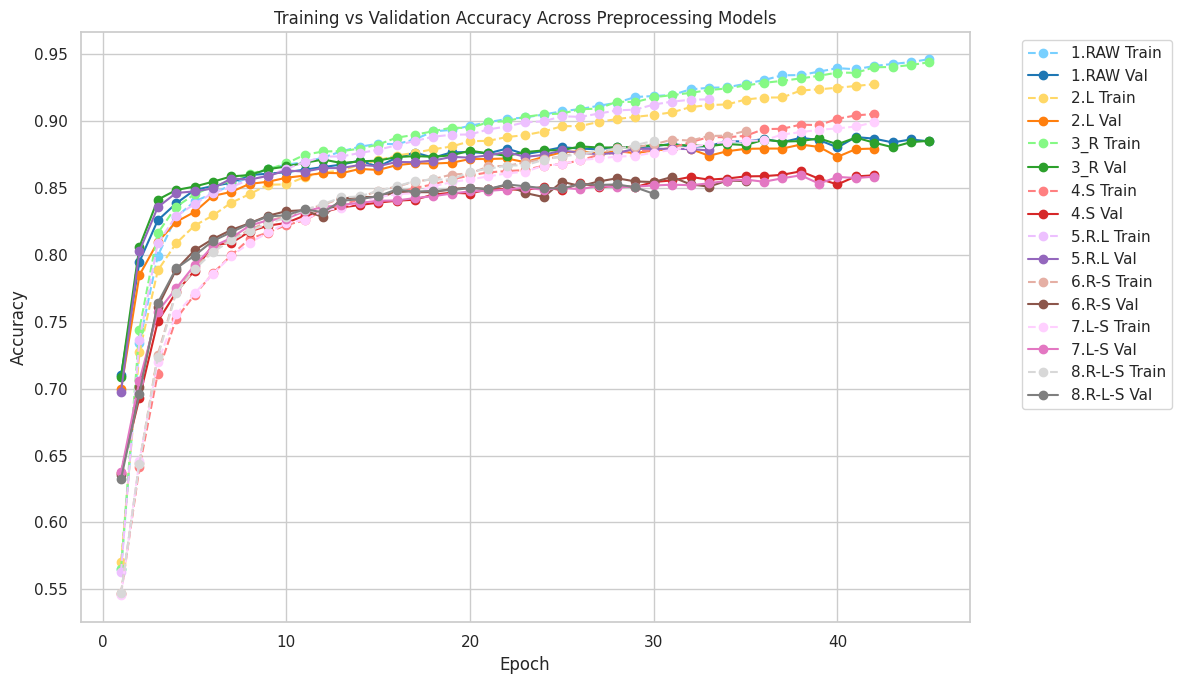

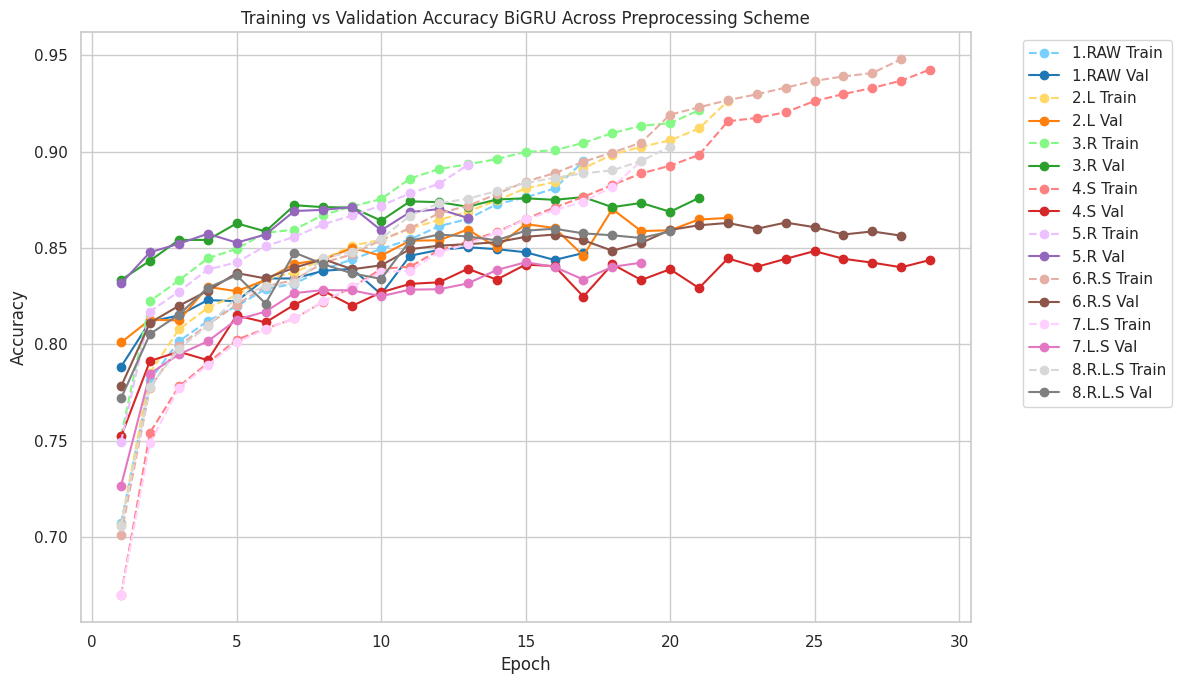

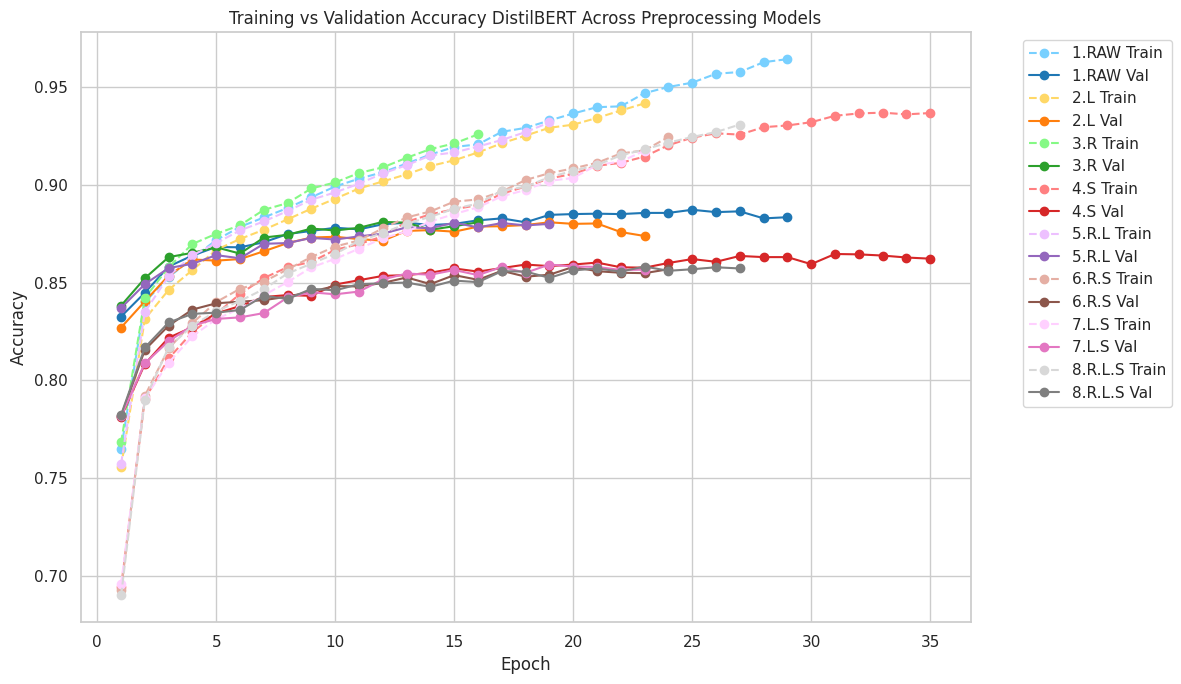

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# PATH FOLDER HYBRID
# =====================================================
BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID"

# =====================================================
# STYLE
# =====================================================
sns.set(style="whitegrid")

plt.figure(figsize=(12,7))

# color palette
palette = sns.color_palette("tab10", 8)

# =====================================================
# LOOP SEMUA MODEL
# =====================================================
i = 0

for folder in sorted(os.listdir(BASE_DIR)):

    folder_path = os.path.join(BASE_DIR, folder)

    if os.path.isdir(folder_path):

        log_path = os.path.join(folder_path, "training_log.csv")

        if os.path.exists(log_path):

            df = pd.read_csv(log_path)

            epochs = df["Epoch"]
            train_acc = df["Train_Acc"]
            val_acc = df["val_Acc"]

            # nama preprocessing
            model_name = folder

            base_color = palette[i]

            # warna muda untuk train
            train_color = tuple(min(1, c + 0.35) for c in base_color)

            # warna tua untuk val
            val_color = base_color

            # =====================================================
            # TRAIN LINE
            # =====================================================
            plt.plot(
                epochs,
                train_acc,
                marker='o',
                linestyle='--',
                color=train_color,
                label=f"{model_name} Train"
            )

            # =====================================================
            # VALIDATION LINE
            # =====================================================
            plt.plot(
                epochs,
                val_acc,
                marker='o',
                linestyle='-',
                color=val_color,
                label=f"{model_name} Val"
            )

            i += 1

# =====================================================
# LABEL
# =====================================================
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy Across Preprocessing Models")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.grid(True)

plt.tight_layout()

# =====================================================
# SAVE
# =====================================================
plt.savefig(os.path.join(BASE_DIR,"training_accuracy_comparison.png"), dpi=300)

plt.show()

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# PATH FOLDER HYBRID
# =====================================================
BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/BiGRU_BASELINE"

# =====================================================
# STYLE
# =====================================================
sns.set(style="whitegrid")

plt.figure(figsize=(12,7))

# color palette
palette = sns.color_palette("tab10", 8)

# =====================================================
# LOOP SEMUA MODEL
# =====================================================
i = 0

for folder in sorted(os.listdir(BASE_DIR)):

    folder_path = os.path.join(BASE_DIR, folder)

    if os.path.isdir(folder_path):

        log_path = os.path.join(folder_path, "training_log.csv")

        if os.path.exists(log_path):

            df = pd.read_csv(log_path)

            epochs = df["epoch"]
            train_acc = df["train_acc"]
            val_acc = df["val_acc"]

            # nama preprocessing
            model_name = folder

            base_color = palette[i]

            # warna muda untuk train
            train_color = tuple(min(1, c + 0.35) for c in base_color)

            # warna tua untuk val
            val_color = base_color

            # =====================================================
            # TRAIN LINE
            # =====================================================
            plt.plot(
                epochs,
                train_acc,
                marker='o',
                linestyle='--',
                color=train_color,
                label=f"{model_name} Train"
            )

            # =====================================================
            # VALIDATION LINE
            # =====================================================
            plt.plot(
                epochs,
                val_acc,
                marker='o',
                linestyle='-',
                color=val_color,
                label=f"{model_name} Val"
            )

            i += 1

# =====================================================
# LABEL
# =====================================================
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy BiGRU Across Preprocessing Scheme")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.grid(True)

plt.tight_layout()

# =====================================================
# SAVE
# =====================================================
plt.savefig(os.path.join(BASE_DIR,"training_accuracy_comparison.png"), dpi=300)

plt.show()

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# PATH FOLDER HYBRID
# =====================================================
BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/DISTILBERT_BASELINE"

# =====================================================
# STYLE
# =====================================================
sns.set(style="whitegrid")

plt.figure(figsize=(12,7))

# color palette
palette = sns.color_palette("tab10", 8)

# =====================================================
# LOOP SEMUA MODEL
# =====================================================
i = 0

for folder in sorted(os.listdir(BASE_DIR)):

    folder_path = os.path.join(BASE_DIR, folder)

    if os.path.isdir(folder_path):

        log_path = os.path.join(folder_path, "training_log.csv")

        if os.path.exists(log_path):

            df = pd.read_csv(log_path)

            epochs = df["epoch"]
            train_acc = df["train_acc"]
            val_acc = df["val_acc"]

            # nama preprocessing
            model_name = folder

            base_color = palette[i]

            # warna muda untuk train
            train_color = tuple(min(1, c + 0.35) for c in base_color)

            # warna tua untuk val
            val_color = base_color

            # =====================================================
            # TRAIN LINE
            # =====================================================
            plt.plot(
                epochs,
                train_acc,
                marker='o',
                linestyle='--',
                color=train_color,
                label=f"{model_name} Train"
            )

            # =====================================================
            # VALIDATION LINE
            # =====================================================
            plt.plot(
                epochs,
                val_acc,
                marker='o',
                linestyle='-',
                color=val_color,
                label=f"{model_name} Val"
            )

            i += 1

# =====================================================
# LABEL
# =====================================================
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy DistilBERT Across Preprocessing Models")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.grid(True)

plt.tight_layout()

# =====================================================
# SAVE
# =====================================================
plt.savefig(os.path.join(BASE_DIR,"training_accuracy_comparison.png"), dpi=300)

plt.show()

In [ ]:
print(df.columns.tolist())

['text', 'actual', 'predicted', 'probability']


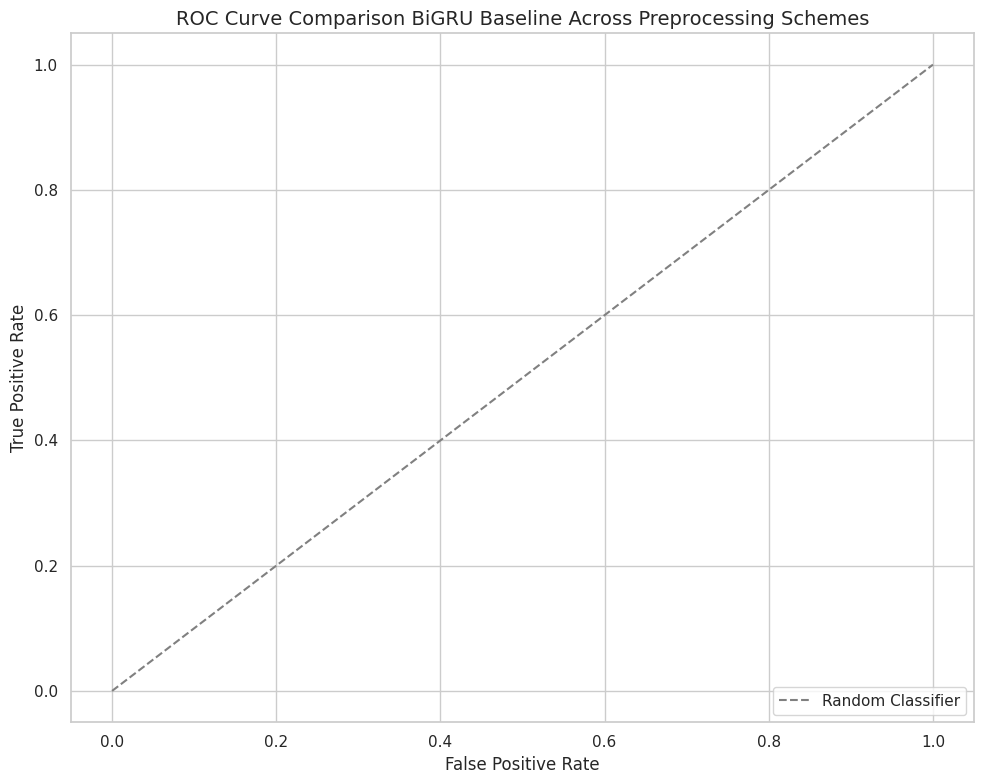

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc

# =====================================================
# PATH
# =====================================================
BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/BiGRU_BASELINE"

# =====================================================
# STYLE
# =====================================================
sns.set(style="whitegrid")

plt.figure(figsize=(10,8))

palette = sns.color_palette("tab10", 8)

# =====================================================
# LOOP SEMUA MODEL
# =====================================================
i = 0

for folder in sorted(os.listdir(BASE_DIR)):

    folder_path = os.path.join(BASE_DIR, folder)

    if os.path.isdir(folder_path):

        pred_path = os.path.join(folder_path, "test_predictions.csv")

        if os.path.exists(pred_path):

            df = pd.read_csv(pred_path)

            y_true = df["actual"]
            y_prob = df["probability"]

            # ROC
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            roc_auc = auc(fpr, tpr)

            # ambil nama preprocessing
            model_name = folder.split(".")[1]

            plt.plot(
                fpr,
                tpr,
                linewidth=2,
                color=palette[i],
                label=f"{model_name} (AUC = {roc_auc:.3f})"
            )

            i += 1

# =====================================================
# RANDOM CLASSIFIER
# =====================================================
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

# =====================================================
# LABEL
# =====================================================
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title("ROC Curve Comparison BiGRU Baseline Across Preprocessing Schemes", fontsize=14)

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

# =====================================================
# SAVE
# =====================================================
plt.savefig(
    os.path.join(BASE_DIR,"roc_auc_comparison_models.png"),
    dpi=300
)

plt.show()

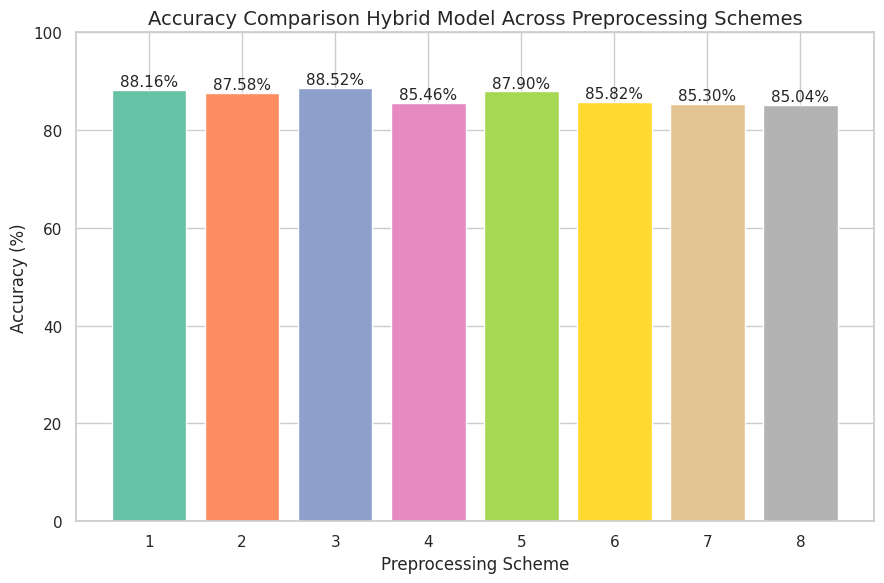

In [ ]:
# =====================================================
# BUAT BAR COMPARISON ACCURACY
# =====================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# PATH FOLDER HYBRID
# =====================================================
BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID"

data = []

# =====================================================
# READ ALL CLASSIFICATION REPORTS
# =====================================================
for folder in os.listdir(BASE_DIR):

    folder_path = os.path.join(BASE_DIR, folder)

    if os.path.isdir(folder_path):

        report_path = os.path.join(folder_path, "classification_report.csv")

        if os.path.exists(report_path):

            df = pd.read_csv(report_path, index_col=0)

            accuracy = df.loc["accuracy","f1-score"]

            # ambil nama preprocessing (RAW, L, R, dll)
            name = folder.split(".")[1]

            data.append({
                "Preprocessing": name,
                "Accuracy": accuracy
            })

# =====================================================
# DATAFRAME
# =====================================================
results = pd.DataFrame(data)
results = results.sort_values("Preprocessing")

# =====================================================
# PLOT STYLE
# =====================================================
sns.set(style="whitegrid")

plt.figure(figsize=(9,6))

colors = sns.color_palette("Set2", len(results))

bars = plt.bar(
    results["Preprocessing"],
    results["Accuracy"]*100,
    color=colors
)

# =====================================================
# LABEL PERSENTASE DI ATAS BAR
# =====================================================
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}%",
        ha='center',
        va='bottom',
        fontsize=11
    )

# =====================================================
# LABEL DAN TITLE
# =====================================================
plt.xlabel("Preprocessing Scheme", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Accuracy Comparison Hybrid Model Across Preprocessing Schemes", fontsize=14)

plt.ylim(0, 100)

plt.tight_layout()

# =====================================================
# SAVE PLOT
# =====================================================
plt.savefig(os.path.join(BASE_DIR,"accuracy_comparison_barplot.png"), dpi=300)

plt.show()

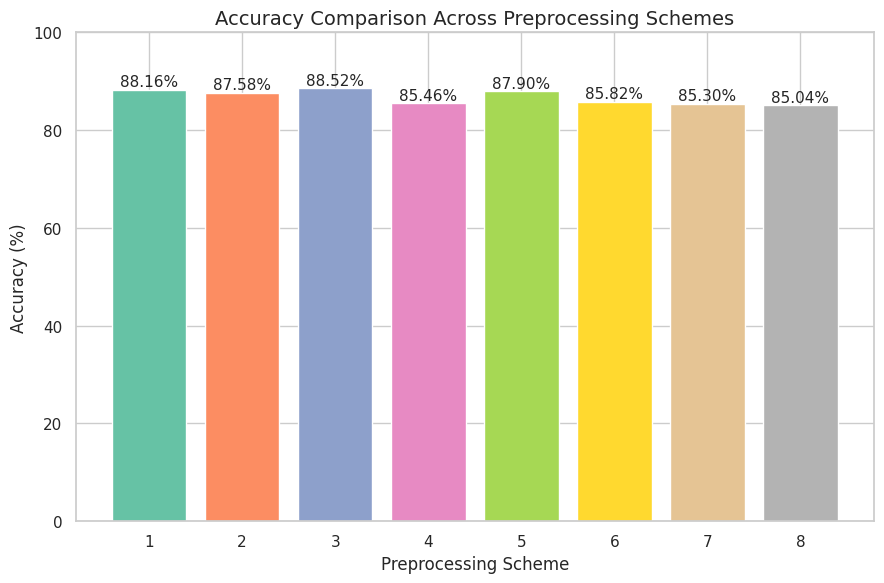

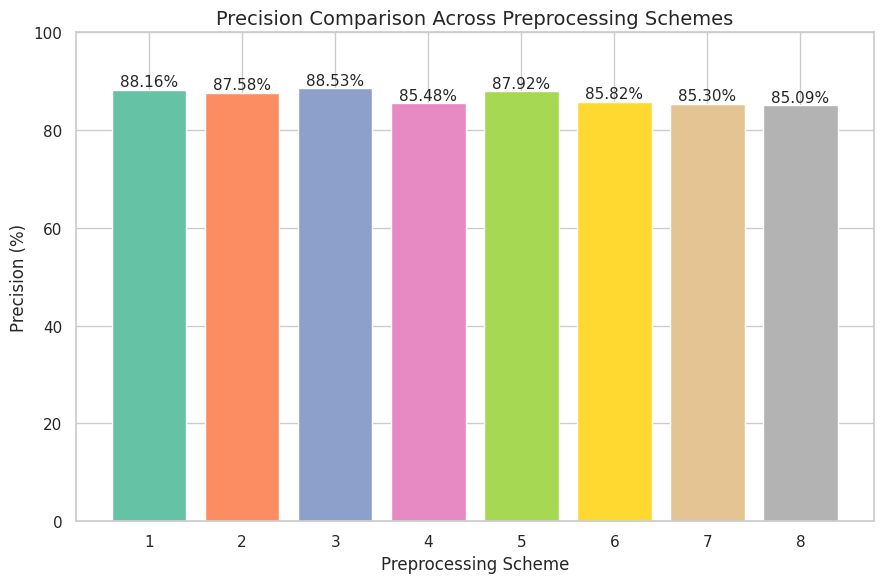

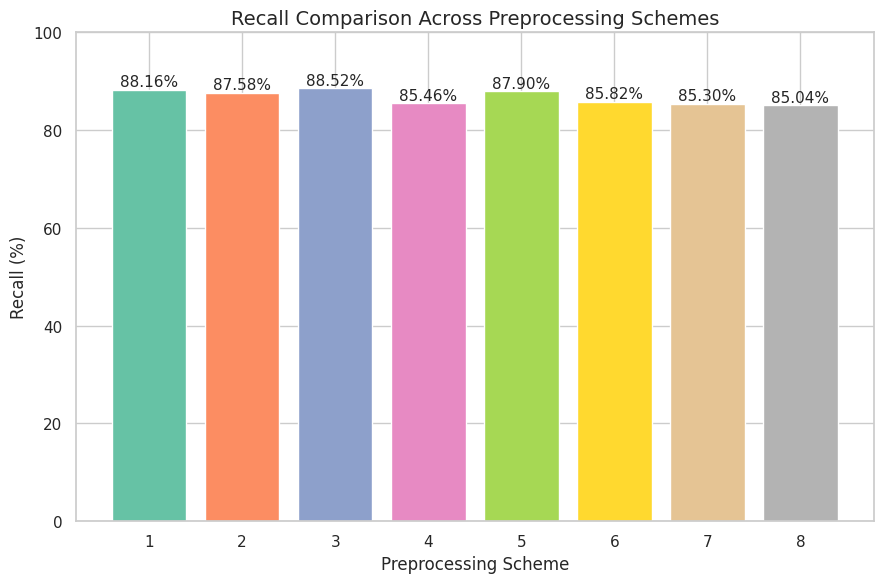

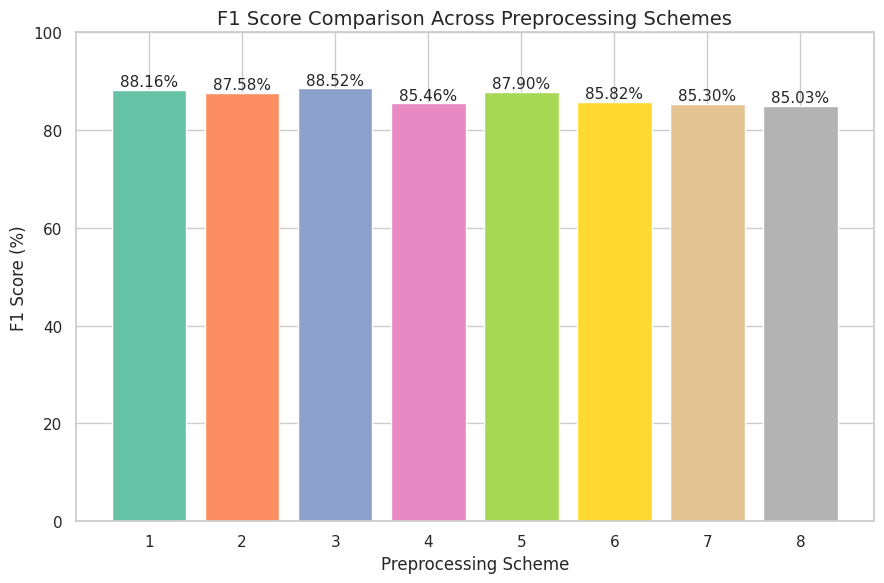

In [ ]:
# =====================================================
# BAR COMPARISON FOR ACCURACY, PRECISION, RECALL, F1
# =====================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# PATH FOLDER HYBRID
# =====================================================
BASE_DIR = r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/HYBRID"

data = []

# =====================================================
# READ ALL CLASSIFICATION REPORTS
# =====================================================
for folder in os.listdir(BASE_DIR):

    folder_path = os.path.join(BASE_DIR, folder)

    if os.path.isdir(folder_path):

        report_path = os.path.join(folder_path, "classification_report.csv")

        if os.path.exists(report_path):

            df = pd.read_csv(report_path, index_col=0)

            accuracy = df.loc["accuracy","f1-score"]
            precision = df.loc["weighted avg","precision"]
            recall = df.loc["weighted avg","recall"]
            f1 = df.loc["weighted avg","f1-score"]

            name = folder.split(".")[1]

            data.append({
                "Preprocessing": name,
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1 Score": f1
            })

# =====================================================
# DATAFRAME
# =====================================================
results = pd.DataFrame(data)
results = results.sort_values("Preprocessing")

# =====================================================
# PLOT STYLE
# =====================================================
sns.set(style="whitegrid")

metrics = ["Accuracy","Precision","Recall","F1 Score"]

for metric in metrics:

    plt.figure(figsize=(9,6))

    colors = sns.color_palette("Set2", len(results))

    bars = plt.bar(
        results["Preprocessing"],
        results[metric]*100,
        color=colors
    )

    # label di atas bar
    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.15,
            f"{height:.2f}%",
            ha='center',
            va='bottom',
            fontsize=11
        )

    plt.xlabel("Preprocessing Scheme", fontsize=12)
    plt.ylabel(f"{metric} (%)", fontsize=12)
    plt.title(f"{metric} Comparison Across Preprocessing Schemes", fontsize=14)

    plt.ylim(0,100)

    plt.tight_layout()

    # save figure
    plt.savefig(
        os.path.join(BASE_DIR,f"{metric.lower()}_comparison_barplot.png"),
        dpi=300
    )

    plt.show()

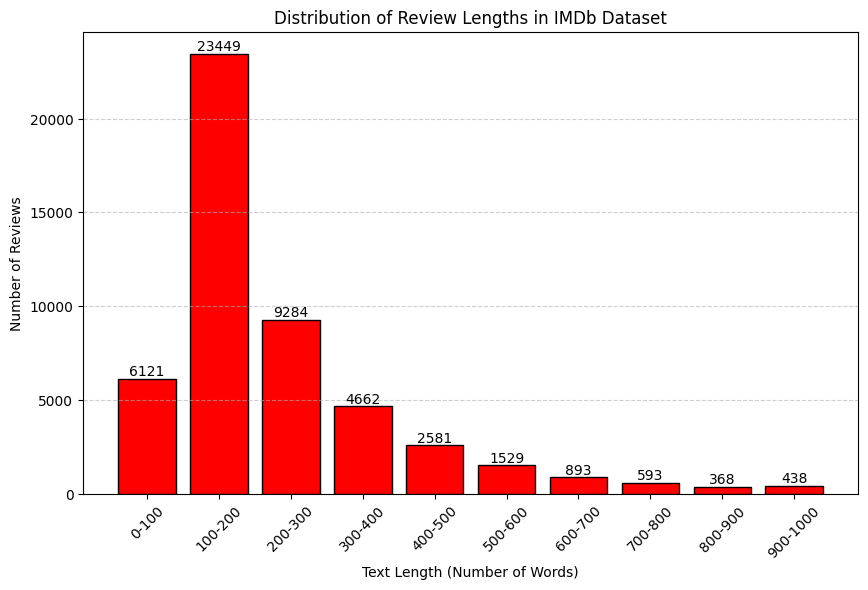

In [ ]:
# ======================================================
# BAR CHART TEXT LENGTH DISTRIBUTION + COUNT LABEL
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/DATA/IMDB Dataset.csv"

# load dataset
df = pd.read_csv(DATA_PATH)

# hitung panjang teks (jumlah kata)
df["text_length"] = df["review"].apply(lambda x: len(str(x).split()))

# buat kategori panjang teks
bins = [0,100,200,300,400,500,600,700,800,900,1000]
labels = [
    "0-100","100-200","200-300","300-400","400-500",
    "500-600","600-700","700-800","800-900","900-1000"
]

df["length_group"] = pd.cut(df["text_length"], bins=bins, labels=labels)

# hitung jumlah per kategori
length_counts = df["length_group"].value_counts().sort_index()

# ======================================================
# PLOT BAR CHART
# ======================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    length_counts.index.astype(str),
    length_counts.values,
    color="red",
    edgecolor="black"
)

# menambahkan jumlah di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel("Text Length (Number of Words)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths in IMDb Dataset")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.xticks(rotation=45)

plt.show()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


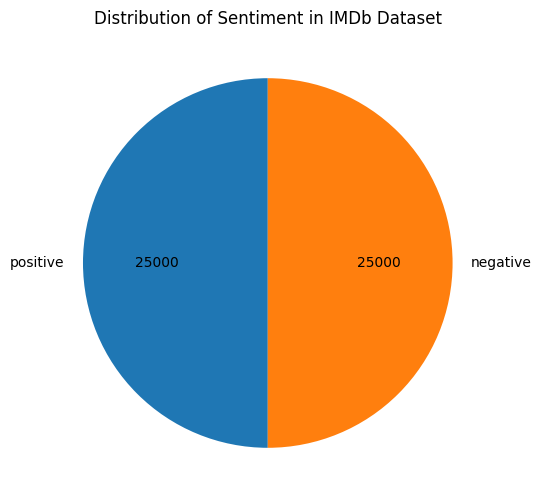

In [ ]:
# ======================================================
# PIE CHART DISTRIBUSI SENTIMEN IMDB DATASET
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt

# path dataset
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/DATA/IMDB Dataset.csv"

# load dataset
df = pd.read_csv(DATA_PATH)

# hitung jumlah sentimen
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

# fungsi untuk menampilkan jumlah
def count_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct*total/100))
        return f'{count}'
    return my_format

# pie chart
plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct=count_format(sentiment_counts),
    startangle=90,
)

plt.title("Distribution of Sentiment in IMDb Dataset")

plt.show()

MENAMPILKAN DATA BARIS KEDUA-KEENAM DARI 16 DATASET

In [ ]:
import pandas as pd
import glob
import os

folder_path = "/content/drive/MyDrive/Colab Notebooks/PREPROCESS"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

samples = []

for file in csv_files:

    df = pd.read_csv(file)

    # ambil baris 2–6
    sample = df.iloc[1:6].copy()

    # tambah kolom sumber file
    sample["source_file"] = os.path.basename(file)

    samples.append(sample)

# gabungkan semua
result = pd.concat(samples, ignore_index=True)

print(result)

save_path = "/content/drive/MyDrive/Colab Notebooks/sample_preview_16_dataset.csv"

result.to_csv(save_path, index=False)

print("File berhasil disimpan di:", save_path)

                                               review  sentiment   source_file
0   wonder littl product . < br / > < br / > film ...          1  11.R-L-S.csv
1   think wonder way spend time hot summer weekend...          1  11.R-L-S.csv
2   basic 's famili littl boy ( jake ) think 's zo...          0  11.R-L-S.csv
3   petter mattei 's `` love time money '' visual ...          1  11.R-L-S.csv
4   probabl all-tim favorit movi , stori selfless ...          1  11.R-L-S.csv
5   A wonderful little production. <br /><br />The...          1     1.RAW.csv
6   I thought this was a wonderful way to spend ti...          1     1.RAW.csv
7   Basically there's a family where a little boy ...          0     1.RAW.csv
8   Petter Mattei's "Love in the Time of Money" is...          1     1.RAW.csv
9   Probably my all-time favorite movie, a story o...          1     1.RAW.csv
10  wonderful little production . < br / > < br / ...          1       3.R.csv
11  thought wonderful way spend time hot summer we..

MENAMPILKAN TEXT AUGMENTASI DATA BEFORE-AFTER

In [ ]:
pip install nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 13.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import nlpaug.augmenter.word as naw
import nltk
nltk.download ('averaged_perceptron_tagger_eng')
# =============================
# LOAD DATASET
# =============================
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/DATA/IMDB Dataset.csv")

# =============================
# LOAD SPLIT INDEX
# =============================
train_idx = np.load(r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/SPLIT IDX/train.npy")
val_idx   = np.load(r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/SPLIT IDX/val.npy")
test_idx  = np.load(r"/content/drive/MyDrive/Colab Notebooks/TESIS FIX/SPLIT IDX/test.npy")

# =============================
# SPLIT DATA
# =============================
train_df = df.iloc[train_idx]
val_df   = df.iloc[val_idx]
test_df  = df.iloc[test_idx]

print("Train size :", len(train_df))
print("Val size   :", len(val_df))
print("Test size  :", len(test_df))

# =============================
# AMBIL SAMPLE TRAIN
# =============================
samples = train_df.sample(10, random_state=42)

# =============================
# AUGMENTER
# =============================
aug = naw.SynonymAug(aug_src='wordnet')

results = []

# =============================
# PREVIEW BEFORE AFTER
# =============================
for _, row in samples.iterrows():

    original = row["review"]
    sentiment = row["sentiment"]

    augmented = aug.augment(original)

    results.append({
        "sentiment": sentiment,
        "original_review": original,
        "augmented_review": augmented
    })

preview_df = pd.DataFrame(results)

print("\nPreview Augmentation (TRAIN SET ONLY)\n")
print(preview_df)

# simpan ke csv
preview_df.to_csv("preview_augmentation_trainset.csv", index=False)

print("\nFile preview_augmentation_trainset.csv berhasil dibuat")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Train size : 40000
Val size   : 5000
Test size  : 5000

Preview Augmentation (TRAIN SET ONLY)

  sentiment                                    original_review  \
0  negative  Why, oh why, is this trash considered a classi...   
1  negative  First off, Mexican Werewolf in Texas' title is...   
2  positive  I rate this 10 out of 10. Why?<br /><br />* It...   
3  negative  Anurag Basu who co-directed the flop KUCCH TO ...   
4  negative  Burt Reynolds came to a point in his career wh...   
5  positive  My daughter already wrote a review of this mov...   
6  positive  This was the best film I saw in the year 2000....   
7  positive  This Norwegian film starts with a man jumping ...   
8  positive  "Hollywood Cavalcade" is a mildly entertaining...   
9  negative  This movie has a slew of great adult stars but...   

                                    augmented_review  
0  [Why, oh why, is this trash considered a class...  
1  [First off, Mexican Werewolf in Texas ' title ...  
2  [I rate th

SEGMENTASI KATA

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Top 10 Positive Words
    Word  Frequency
0   film      39437
1  movie      36043
2    one      25739
3   like      17057
4   good      14352
5  great      12647
6  story      12381
7    see      11869
8   time      11786
9   well      10980

Top 10 Negative Words
     Word  Frequency
0   movie      47535
1    film      35077
2     one      24653
3    like      21777
4    even      14920
5    good      14150
6     bad      14095
7   would      13633
8  really      12224
9    time      11513


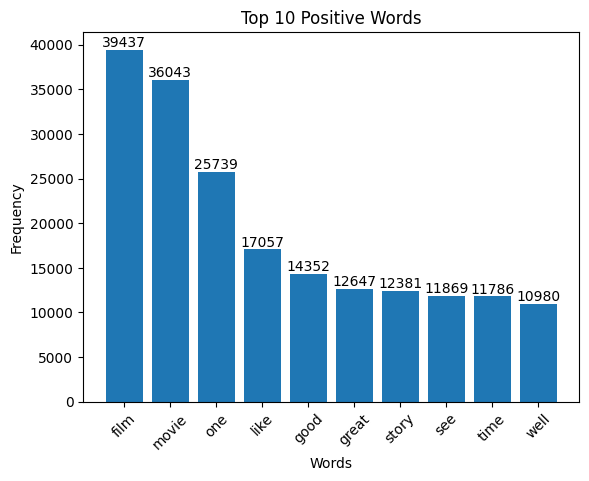

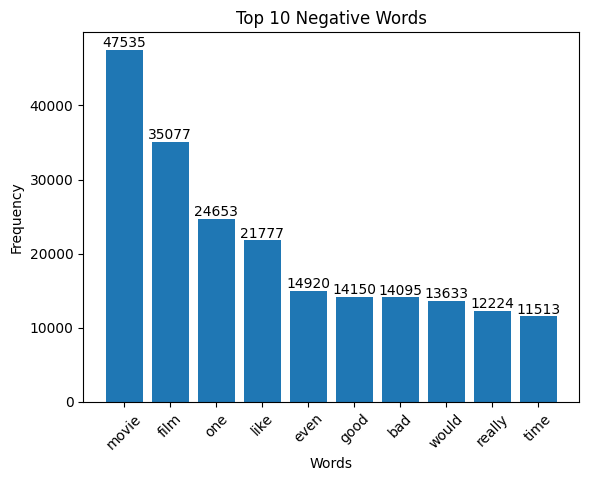

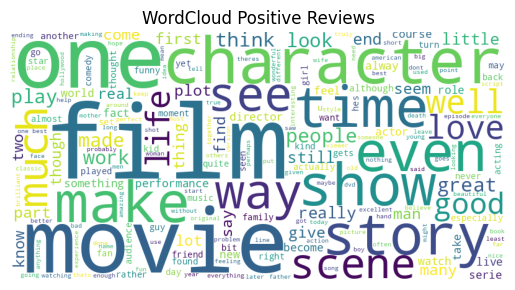

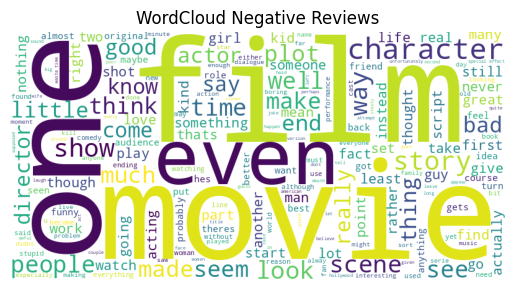


Top 10 Positive Bigrams
('one', 'best') : 1608
('ive', 'seen') : 1061
('even', 'though') : 1016
('ever', 'seen') : 916
('first', 'time') : 904
('dont', 'know') : 862
('new', 'york') : 802
('special', 'effects') : 763
('see', 'movie') : 718
('years', 'ago') : 703

Top 10 Negative Bigrams
('ever', 'seen') : 1617
('special', 'effects') : 1371
('waste', 'time') : 1355
('looks', 'like') : 1220
('dont', 'know') : 1192
('ive', 'seen') : 1087
('much', 'better') : 957
('one', 'worst') : 943
('look', 'like') : 930
('even', 'though') : 852


In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

# =========================
# Download stopwords
# =========================
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# =========================
# Load Dataset
# =========================
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATA/IMDB Dataset.csv")

# =========================
# Text Cleaning
# =========================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["clean_review"] = df["review"].apply(clean_text)

# =========================
# Pisahkan Sentiment
# =========================
pos_reviews = df[df["sentiment"] == "positive"]["clean_review"]
neg_reviews = df[df["sentiment"] == "negative"]["clean_review"]

# =========================
# Tokenisasi
# =========================
pos_words = " ".join(pos_reviews).split()
neg_words = " ".join(neg_reviews).split()

# Remove stopwords
pos_words = [w for w in pos_words if w not in stop_words]
neg_words = [w for w in neg_words if w not in stop_words]

# =========================
# Word Frequency
# =========================
pos_freq = Counter(pos_words)
neg_freq = Counter(neg_words)

top10_pos = pos_freq.most_common(10)
top10_neg = neg_freq.most_common(10)

pos_df = pd.DataFrame(top10_pos, columns=["Word", "Frequency"])
neg_df = pd.DataFrame(top10_neg, columns=["Word", "Frequency"])

print("\nTop 10 Positive Words")
print(pos_df)

print("\nTop 10 Negative Words")
print(neg_df)

# =========================
# BAR PLOT POSITIVE
# =========================
plt.figure()
bars = plt.bar(pos_df["Word"], pos_df["Frequency"])
plt.title("Top 10 Positive Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, int(y), ha='center', va='bottom')

plt.show()

# =========================
# BAR PLOT NEGATIVE
# =========================
plt.figure()
bars = plt.bar(neg_df["Word"], neg_df["Frequency"])
plt.title("Top 10 Negative Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, int(y), ha='center', va='bottom')

plt.show()

# =========================
# WORDCLOUD POSITIVE
# =========================
wordcloud_pos = WordCloud(width=800, height=400, background_color="white").generate(" ".join(pos_words))

plt.figure()
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("WordCloud Positive Reviews")
plt.show()

# =========================
# WORDCLOUD NEGATIVE
# =========================
wordcloud_neg = WordCloud(width=800, height=400, background_color="white").generate(" ".join(neg_words))

plt.figure()
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud Negative Reviews")
plt.show()

# =========================
# BIGRAM ANALYSIS
# =========================
pos_bigrams = list(ngrams(pos_words, 2))
neg_bigrams = list(ngrams(neg_words, 2))

pos_bigram_freq = Counter(pos_bigrams).most_common(10)
neg_bigram_freq = Counter(neg_bigrams).most_common(10)

print("\nTop 10 Positive Bigrams")
for bg, freq in pos_bigram_freq:
    print(bg, ":", freq)

print("\nTop 10 Negative Bigrams")
for bg, freq in neg_bigram_freq:
    print(bg, ":", freq)